# Tutorial 8: Merger trees

This is the tutorial the whole series has been building toward: construct
dark-matter-halo **merger trees** with Galacticus's Cole et al. (2000)
algorithm, walk their nodes, and read halo properties along the way —
entirely from Python.

Three library capabilities combine here:

* **opaque object handles** — `mergerTreeConstructor.construct` returns a
  tree as a handle you pass into other Galacticus objects;
* **the pointer write-back protocol** — tree walkers advance your node
  handle in place: `while walker.next(node): …`;
* **property extraction** — `extractScalar(node)` reads any scalar node
  property through the `nodePropertyExtractor` family.

The tree-building ingredients themselves are the objects from Tutorials
2, 3 and 5: the $\sigma(M)$ chain, collapse thresholds, branching rates
and root-mass sampling.

In [1]:
import os, sys

# Locate the Galacticus library interface (see Tutorial 1 for details).
root = os.environ.get('GALACTICUS_LIBRARY_PATH',
                      os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
os.chdir(root)   # galacticus.py loads galacticus/lib/libgalacticus.so relative to here
for candidate in (root, os.path.join(root, 'galacticus', 'python')):
    if os.path.exists(os.path.join(candidate, 'galacticus.py')):
        sys.path.insert(0, candidate)
        break
else:
    raise RuntimeError(f"galacticus.py not found under {root} - build the library "
                       "(make GALACTICUS_BUILD_OPTION=lib libgalacticus.so) or set "
                       "GALACTICUS_LIBRARY_PATH")

import ctypes
import numpy as np
import matplotlib.pyplot as plt
import galacticus
# Creating tree nodes requires the node-component class system; initialize
# it once (idempotent) with default component selections.
galacticus.nodesInitialize()
print("Galacticus library interface loaded; node system initialized.")

Galacticus library interface loaded; node system initialized.


In [2]:
plt.rcParams.update({'figure.figsize': (7.0, 4.5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

## The object graph

Everything a Galacticus run would assemble from a parameter file, built
by hand: the $\sigma(M)$ chain (Tutorials 2–3), the Parkinson–Cole–Helly
branching rates (Tutorial 5), the Cole et al. (2000) tree builder, and
the tree constructor that ties them together with a root-mass sampler.

In [3]:
cosmologyParameters = galacticus.cosmologyParametersSimple(0.3, 0.045, 0.7, 2.78, 70.0)
cosmologyFunctions  = galacticus.cosmologyFunctionsMatterLambda(cosmologyParameters)
darkMatterParticle  = galacticus.darkMatterParticleCDM()
transferFunction    = galacticus.transferFunctionEisensteinHu1999(
    3.046, 0.0, darkMatterParticle, cosmologyParameters, cosmologyFunctions)
linearGrowth        = galacticus.linearGrowthCollisionlessMatter(cosmologyParameters, cosmologyFunctions)
powerSpectrumPrimordial = galacticus.powerSpectrumPrimordialPowerLaw(0.965, 0.0, 0.0, 1.0, False)
powerSpectrum       = galacticus.powerSpectrumPrimordialTransferredSimple(
    powerSpectrumPrimordial, transferFunction, linearGrowth)
powerSpectrumWindowFunction = galacticus.powerSpectrumWindowFunctionTopHat(cosmologyParameters)
cosmologicalMassVariance = galacticus.cosmologicalMassVarianceFilteredPower(
    sigma8=0.8, tolerance=1.0e-4, toleranceTopHat=1.0e-4, nonMonotonicIsFatal=True,
    integrationFailureIsFatal=True, monotonicInterpolation=False,
    rootVarianceLogarithmicGradientTolerance=1.0e-4, truncateAtParticleHorizon=False,
    storeTabulations=True, cosmologyParameters_=cosmologyParameters,
    cosmologyFunctions_=cosmologyFunctions, linearGrowth_=linearGrowth,
    powerSpectrumPrimordialTransferred_=powerSpectrum,
    powerSpectrumWindowFunction_=powerSpectrumWindowFunction)
criticalOverdensity = galacticus.criticalOverdensitySphericalCollapseClsnlssMttrCsmlgclCnstnt(
    linearGrowth, cosmologyFunctions, cosmologicalMassVariance, darkMatterParticle, True)
haloMassFunction    = galacticus.haloMassFunctionShethTormen(
    cosmologyParameters, cosmologicalMassVariance, criticalOverdensity, 0.707, 0.3, 0.322183)
branchingProbability = galacticus.mergerTreeBranchingProbabilityParkinsonColeHelly(
    0.57, 0.38, -0.01, 0.1, 1.0e-6, True, True, False,
    cosmologicalMassVariance, criticalOverdensity)
randomNumberGenerator = galacticus.randomNumberGeneratorGSL(
    seed_=8675309, ompThreadOffset=False, mpiRankOffset=False)

ageToday     = cosmologyFunctions.cosmicTime(1.0)
timeEarliest = cosmologyFunctions.cosmicTime(cosmologyFunctions.expansionFactorFromRedshift(1.0e5))

# The Cole et al. (2000) tree-build algorithm (canonical parameters), with
# progenitors resolved down to 1e10 Msun.
massResolution = galacticus.mergerTreeMassResolutionFixed(1.0e10)
buildController = galacticus.mergerTreeBuildControllerUncontrolled(branchingProbability)
treeBuilder = galacticus.mergerTreeBuilderCole2000(
    0.1, 0.1,                # mergeProbability, accretionLimit
    timeEarliest, 2.0e-6,    # earliest epoch and its tolerance
    True, 1.0e-6, 1.0e-3,    # branchIntervalStep, resolution tolerances
    False, False,            # ignoreNoProgress, ignoreWellOrdering
    branchingProbability, massResolution, cosmologyFunctions,
    criticalOverdensity, cosmologicalMassVariance, buildController)

# Root masses: 8 trees, uniform in log mass over 1e12..1e13 Msun.
massDistribution = galacticus.mergerTreeBuildMassDistributionPowerLaw(0.0)
buildMasses      = galacticus.mergerTreeBuildMassesSampledDistributionUniform(
    1.0e12, 1.0e13, 8.0, massDistribution)
treeSeeds   = galacticus.mergerTreeSeedsRandom(randomNumberGenerator)
outputTimes = galacticus.outputTimesList(np.array([ageToday]), cosmologyFunctions)
treeConstructor = galacticus.mergerTreeConstructorBuild(
    ageToday, 1.0e-6, 0, True,
    cosmologyParameters, cosmologyFunctions, buildMasses, treeBuilder,
    treeSeeds, haloMassFunction, outputTimes, randomNumberGenerator)
print("tree machinery assembled.")

tree machinery assembled.


## Build a tree

`construct(treeNumber, finished)` builds tree number $n$ of the suite and
returns it as an **opaque handle** (an address you never dereference in
Python — you hand it to other Galacticus objects). The `finished`
argument is a plain `intent(out)` logical: pass a `ctypes.c_bool` and read
it afterwards; it turns `True` once the suite is exhausted. The tree's
memory is owned by Galacticus.

In [4]:
finished = ctypes.c_bool(False)
tree = treeConstructor.construct(1, finished)
print(f"tree handle : {hex(tree)}")
print(f"suite done  : {finished.value}")
assert tree != 0

tree handle : 0x20722500
suite done  : False


## Walk the tree and read its nodes

A `mergerTreeWalker` visits every node. The `node` argument is a
`ctypes.c_void_p` **updated in place** by each call (Fortran repoints it);
start it as `None`, loop until `next` returns `False`. At each node any
scalar `nodePropertyExtractor` can be evaluated through `extractScalar` —
here the basic mass and cosmic time.

nodes in tree      : 1207
root mass          : 8.660e+12 Msun
earliest progenitor: t = 0.60 Gyr (z = 8.3)


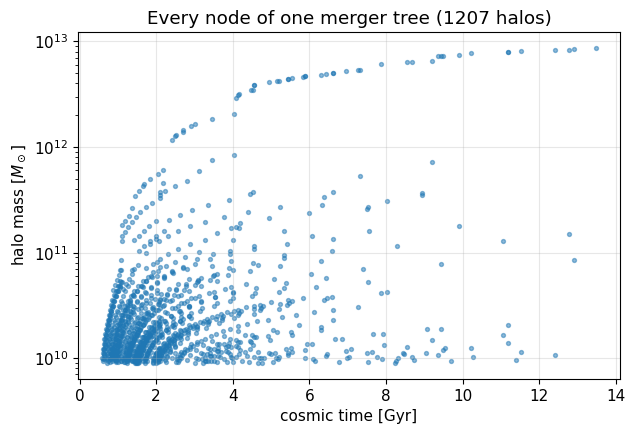

In [5]:
extractorMass = galacticus.nodePropertyExtractorMassBasic()
extractorTime = galacticus.nodePropertyExtractorTime()

walker = galacticus.mergerTreeWalkerIsolatedNodes(tree)
node   = ctypes.c_void_p(None)
masses, times = [], []
while walker.next(node):
    masses.append(extractorMass.extractScalar(node))
    times.append(extractorTime.extractScalar(node))
masses, times = np.array(masses), np.array(times)

print(f"nodes in tree      : {masses.size}")
print(f"root mass          : {masses.max():.3e} Msun")
print(f"earliest progenitor: t = {times.min():.2f} Gyr "
      f"(z = {cosmologyFunctions.redshiftFromExpansionFactor(cosmologyFunctions.expansionFactor(times.min())):.1f})")
assert masses.size > 10
# Terminal nodes can undershoot the resolution mass by at most the
# accretionLimit fraction (a branch halts once it drops below resolution).
assert masses.min() >= 0.999*0.9e10
assert abs(times.max()-ageToday) < 1.0e-3

plt.scatter(times, masses, s=8, alpha=0.5)
plt.yscale('log')
plt.xlabel('cosmic time [Gyr]'); plt.ylabel('halo mass [$M_\\odot$]')
plt.title(f'Every node of one merger tree ({masses.size} halos)')
plt.show()

The classic wedge: many small progenitors at early times, merging into
ever fewer, more massive halos — hierarchical assembly, node by node.

## Assembly histories across the tree suite

Building the whole suite and tracking, at each epoch, the most massive
progenitor of each tree gives (a close proxy for) the **main-branch mass
accretion history** — steep early growth flattening toward today, with
more massive trees assembling later, and tree-to-tree scatter from the
stochastic branching.

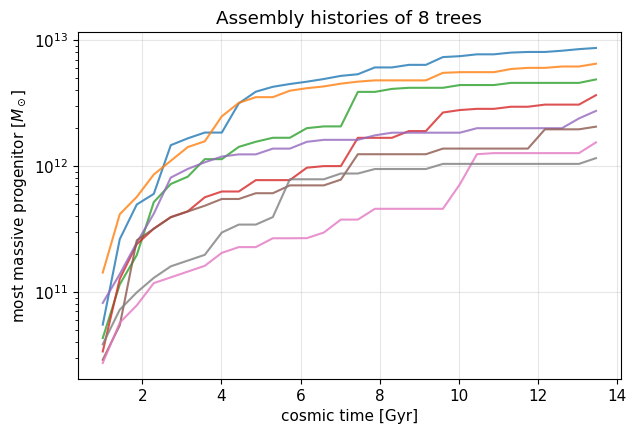

  tree 1: root 8.66e+12 Msun, 1207 nodes
  tree 2: root 6.49e+12 Msun,  747 nodes
  tree 3: root 4.87e+12 Msun,  775 nodes
  tree 4: root 3.65e+12 Msun,  577 nodes
  tree 5: root 2.74e+12 Msun,  353 nodes
  tree 6: root 2.05e+12 Msun,  324 nodes
  tree 7: root 1.54e+12 Msun,  313 nodes
  tree 8: root 1.15e+12 Msun,  168 nodes


In [6]:
timeBins = np.linspace(1.0, ageToday, 30)
fig, ax = plt.subplots()
treeNumber, done = 0, ctypes.c_bool(False)
rootMasses, nodeCounts = [], []
while not done.value:
    treeNumber += 1
    treeN = treeConstructor.construct(treeNumber, done)
    if treeN is None or done.value:   # a null handle (None) means the suite is exhausted
        break
    walkerN = galacticus.mergerTreeWalkerIsolatedNodes(treeN)
    nodeN   = ctypes.c_void_p(None)
    m, t = [], []
    while walkerN.next(nodeN):
        m.append(extractorMass.extractScalar(nodeN))
        t.append(extractorTime.extractScalar(nodeN))
    m, t = np.array(m), np.array(t)
    rootMasses.append(m.max()); nodeCounts.append(m.size)
    # Most massive progenitor per epoch (main-branch proxy).
    history = np.array([m[t <= tb].max() if np.any(t <= tb) else np.nan
                        for tb in timeBins])
    ax.plot(timeBins, history, alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel('cosmic time [Gyr]')
ax.set_ylabel('most massive progenitor [$M_\\odot$]')
ax.set_title(f'Assembly histories of {len(rootMasses)} trees')
plt.show()
for i, (mRoot, n) in enumerate(zip(rootMasses, nodeCounts), start=1):
    print(f"  tree {i}: root {mRoot:.2e} Msun, {n:4d} nodes")

More massive roots come with richer trees — the node count grows steeply
with root mass, which is exactly the resolution/cost trade-off Tutorial 5
measured through `branchingProbability`.

## Halo-scale physics along the walk

Node handles plug into any exposed per-node method. Here
`darkMatterHaloScale` turns each node of our first tree into virial
radii and velocities:

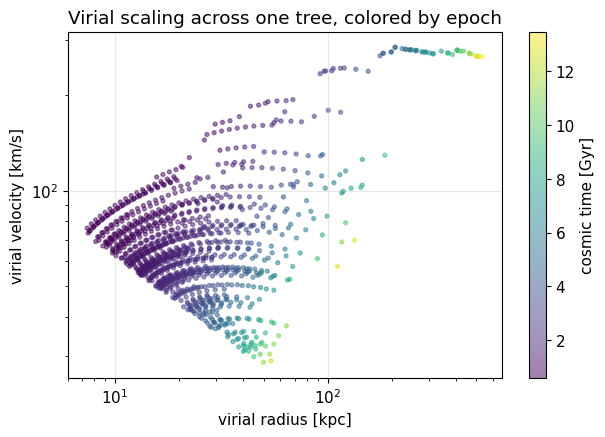

root halo: R_vir = 530 kpc, V_vir = 265 km/s


In [7]:
virialDensityContrast = galacticus.virialDensityContrastSphericalCollapseClsnlssMttrCsmlgclCnstnt(
    True, cosmologyFunctions)
darkMatterHaloScale = galacticus.darkMatterHaloScaleVirialDensityContrastDefinition(
    cosmologyParameters, cosmologyFunctions, virialDensityContrast)

walker = galacticus.mergerTreeWalkerIsolatedNodes(tree)
node   = ctypes.c_void_p(None)
radii, velocities = [], []
while walker.next(node):
    radii     .append(darkMatterHaloScale.radiusVirial  (node))
    velocities.append(darkMatterHaloScale.velocityVirial(node))
radii, velocities = np.array(radii), np.array(velocities)

plt.scatter(1.0e3*radii, velocities, s=8, alpha=0.5, c=times, cmap='viridis')
plt.colorbar(label='cosmic time [Gyr]')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('virial radius [kpc]'); plt.ylabel('virial velocity [km/s]')
plt.title('Virial scaling across one tree, colored by epoch')
plt.show()
print(f"root halo: R_vir = {1.0e3*radii[times.argmax()]:.0f} kpc, "
      f"V_vir = {velocities[times.argmax()]:.0f} km/s")

## Practical notes

* **Initialization**: call `galacticus.nodesInitialize()` once before any
  tree or node is created (the setup cell here does it).
* **Handles are Fortran-owned**: tree and node handles are addresses into
  Galacticus's memory. Don't use a node handle after its tree has been
  rebuilt or destroyed; trees built here live until the process exits.
* **Determinism**: the tree suite is reproducible through the random
  number generator's seed.
* **Where next**: everything downstream of tree building — evolving the
  galaxies inside these halos — is the job of `Galacticus.exe` and its
  `nodeOperator`/`mergerTreeEvolver` machinery; see the user guide for
  the parameter files that do what this notebook did, at scale.